In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
df_5 = pd.read_csv("../data/processed/df_final_poblacion.csv")

df_5

,Municipio,Delitos,Año,Periodo Trimestral,Trimestre,Provincia,Total,Valor trimestral,Poblacion
0,Alaquàs,Delitos Sexuales,2021,Enero-Marzo,1,Valencia,2,2.0,29649
1,Alaquàs,Delitos Sexuales,2021,Enero-Junio,2,Valencia,2,0.0,29649
2,Alaquàs,Delitos Sexuales,2021,Enero-Septiembre,3,Valencia,2,0.0,29649
3,Alaquàs,Delitos Sexuales,2021,Enero-Diciembre,4,Valencia,4,2.0,29649
4,Alaquàs,Delitos Sexuales,2022,Enero-Marzo,1,Valencia,0,0.0,29537
...,...,...,...,...,...,...,...,...,...
36239,Xàtiva,Trafico De Drogas,2024,Enero-Septiembre,3,Valencia,2,0.0,30378
36240,Xàtiva,Trafico De Drogas,2024,Enero-Diciembre,4,Valencia,4,2.0,30378
36241,Xàtiva,Trafico De Drogas,2025,Enero-Marzo,1,Valencia,2,2.0,31008
36242,Xàtiva,Trafico De Drogas,2025,Enero-Junio,2,Valencia,3,1.0,31008


# Análisis Univariante. 

> - La variable objetivo `Total` representa el número total de delitos registrados por tipología, ámbito geográfico y periodo temporal. Su distribución presenta una fuerte asimetría positiva, con una elevada concentración de valores bajos y la presencia de valores extremos, lo cual es característico de variables de conteo asociadas a fenómenos poco frecuentes en determinadas combinaciones espaciales y temporales. 

In [3]:
df_5['Total'].describe().T

count     36244.000000
mean        427.967774
std        4018.794468
min           0.000000
25%           2.000000
50%          14.000000
75%          81.000000
max      112272.000000
Name: Total, dtype: float64

La variable objetivo `Total` presenta una distribución fuertemente asimétrica a la derecha. La media (297,4) es superior a la mediana (16), lo que indica la presencia de valores extremos que concentran gran parte del volumen total de delitos. Asimismo, el 75% de los registros presenta valores inferiores a 91, mientras que el valor máximo alcanza los 112,272 delitos. Esta elevada dispersión, junto con la presencia de numerosos valores bajos y nulos, es característica de variables de conteo asociadas a fenómenos heterogéneos en el espacio y el tiempo

# ANÁLISIS BIVARIANTE

> - `Año` - `Total`.

In [4]:
df_5.groupby('Año')['Total'].sum()

Año
2016    1439759
2017    1769640
2018    1872382
2019    1922939
2020    1174536
2021    1274988
2022    1676563
2023    1748636
2024    1675232
2025     956589
Name: Total, dtype: int64

El análisis bivariante entre la variable `Total` y el `Año` muestra una tendencia creciente en el volumen total de delitos desde 2016 hasta 2019. En 2020 se observa una caída abrupta que rompe el patrón previo, seguida de una recuperación en los años posteriores, alcanzando un máximo en 2023. `(1182288)` 
> - Los valores del 2025 hay valores pendientes a subir por la plataforma Policía Municipal. Datos estadísticos de la Policía Municipal. ya que corresponden al ultimo trimestre incompleto.

> - `Poblacion` - `Total`

In [5]:
df_5.groupby('Poblacion')['Total'].mean()

Poblacion
1,825,332     787.259259
1,836,459    3144.666667
1,838,819     786.074074
1,858,683     794.296296
1,879,888     459.027778
                ...     
98,533        265.444444
98086         131.027778
98590         125.500000
98621         146.833333
99037          91.444444
Name: Total, Length: 1097, dtype: float64

El análisis bivariante entre `población` y `total` de delitos muestra una relación positiva clara: los municipios con mayor población presentan, en promedio, un mayor número absoluto de delitos. Este comportamiento es consistente con la naturaleza agregada de la variable Total y refleja un efecto de escala poblacional más que un mayor nivel relativo de criminalidad. Por tanto, la población actúa como un factor estructural explicativo del volumen de delitos, pero no permite por sí sola evaluar el riesgo o la intensidad delictiva sin normalización.

> - `Trimeste` - `Total`.

In [6]:
df_5.groupby('Trimestre')['Total'].mean()

Trimestre
1    172.362656
2    346.458099
3    509.801340
4    717.262251
Name: Total, dtype: float64

Se observa un incremento progresivo del volumen medio de delitos: (Patron ordenado)

> - T1 → nivel más bajo
> - T2 → incremento moderado
> - T3 → aumento significativo
> - T4 → máximo del año

El análisis bivariante entre la variable `Total` y el `Trimestre` muestra un patrón estacional claramente definido. El volumen medio de delitos aumenta de forma progresiva desde el primer hasta el cuarto trimestre, alcanzando su valor máximo en T4. Esta evolución sugiere la existencia de una estacionalidad marcada en la distribución de los delitos, lo que justifica la inclusión del trimestre como variable explicativa en el análisis posterior.

> - `Provincia` - `Total`.

In [7]:
df_5.groupby('Provincia')['Total'].mean()

Provincia
Alicante     123.362980
Barcelona    524.188765
Castellón     37.251549
Madrid       679.910816
Valencia     138.335854
Name: Total, dtype: float64

Diferencias claras entre provincias

> - Madrid presenta el valor medio más alto de delitos.
> - Barcelona presenta el valor medio de delitos. 
> - Alicante y Valencia muestran valores medios muy similares entre sí.
> - Castellon presenta el valor mas bajo en delitos.
> - La diferencia de Madrid respecto a las otras provincias es sistemática.



El análisis bivariante entre la variable `Total` y la `Provincia` revela diferencias significativas en el volumen medio de delitos registrados. Madrid presenta el valor medio más elevado, mientras que Alicante y Valencia muestran niveles similares entre sí. Estos resultados evidencian una heterogeneidad territorial en la distribución de los delitos, lo que justifica la inclusión de la provincia como variable explicativa en el análisis posterior.

> - `Delitos` - `Total`.

In [8]:
df_5.groupby('Delitos')['Total'].mean()

Delitos
Daños                       1215.822660
Delitos Sexuales              49.705173
Homicidios                     2.769965
Hurtos                      2655.007168
Lesiones                      58.262180
Robos Con Fuerza             451.455550
Robos Con Violencia          304.068559
Secuestro                      0.164741
Sustraccion De Vehiculos     126.349573
Trafico De Drogas             50.229533
Name: Total, dtype: float64

## Diferencias entre categorías:

> - Hurtos y Daños presentan valores medios muy superiores al resto.
> - Tipologías violentas graves (homicidios, secuestros) tienen medias muy bajas.
> - Existe una clara separación entre: delitos frecuentes y delitos graves poco frecuentes

El análisis bivariante entre la variable `Total` y la tipología de `Delitos` revela una marcada heterogeneidad entre categorías. Delitos como hurtos y daños concentran los valores medios más elevados, mientras que tipologías de mayor gravedad, como homicidios o secuestros, presentan valores medios significativamente inferiores. Esta distribución desigual pone de manifiesto que el volumen total de delitos se encuentra fuertemente concentrado en un número reducido de tipologías, justificando la inclusión de esta variable como uno de los principales factores explicativos del modelo.

In [9]:
top_10_municipios = (df_5.groupby('Municipio')['Total'].sum().sort_values(ascending=False).head(10))

top_10_municipios

Municipio
Madrid                          5859760
Barcelona                       5268052
Valencia                         617585
Hospitalet de Llobregat (L')     228262
Alicante                         211165
Badalona                         150271
Prat de Llobregat (El)           139093
Leganés                          110633
Sabadell                          97760
Elche                             91112
Name: Total, dtype: int64

El análisis de los municipios con mayor volumen total de delitos muestra una clara concentración de la criminalidad en grandes núcleos urbanos y áreas metropolitanas. Madrid y Barcelona son las que mas destacan sobre el resto de municipios, seguidos por otras ciudades de gran tamaño como Valencia, Alicante o Elche, así como municipios. Estos resultados evidencian una distribución espacial altamente desigual del fenómeno delictivo, influida por la densidad urbana y la actividad socioeconómica.

In [10]:
top_10_municipios_tranquilos = (df_5.groupby('Municipio')['Total'].sum().sort_values(ascending=True).head(10))

top_10_municipios_tranquilos

Municipio
Silla                     431
Calella                   735
Vila-Real                1084
Sant Just Desvern        1241
Castellar del Vallès     1387
San Martín de la Vega    1450
Manlleu                  1469
Puçol                    1488
Olesa de Montserrat      1784
Esparreguera             1844
Name: Total, dtype: int64

El análisis de los municipios con menor volumen total de delitos muestra que la criminalidad se concentra en menor medida en localidades de pequeño tamaño y baja densidad urbana. Los valores observados son reducidos y relativamente homogéneos, en contraste con la fuerte concentración detectada en grandes núcleos urbanos. Este resultado refuerza la existencia de una marcada desigualdad territorial en la distribución del fenómeno delictivo.

In [11]:
df_5

,Municipio,Delitos,Año,Periodo Trimestral,Trimestre,Provincia,Total,Valor trimestral,Poblacion
0,Alaquàs,Delitos Sexuales,2021,Enero-Marzo,1,Valencia,2,2.0,29649
1,Alaquàs,Delitos Sexuales,2021,Enero-Junio,2,Valencia,2,0.0,29649
2,Alaquàs,Delitos Sexuales,2021,Enero-Septiembre,3,Valencia,2,0.0,29649
3,Alaquàs,Delitos Sexuales,2021,Enero-Diciembre,4,Valencia,4,2.0,29649
4,Alaquàs,Delitos Sexuales,2022,Enero-Marzo,1,Valencia,0,0.0,29537
...,...,...,...,...,...,...,...,...,...
36239,Xàtiva,Trafico De Drogas,2024,Enero-Septiembre,3,Valencia,2,0.0,30378
36240,Xàtiva,Trafico De Drogas,2024,Enero-Diciembre,4,Valencia,4,2.0,30378
36241,Xàtiva,Trafico De Drogas,2025,Enero-Marzo,1,Valencia,2,2.0,31008
36242,Xàtiva,Trafico De Drogas,2025,Enero-Junio,2,Valencia,3,1.0,31008


## Limpieza final de población.



In [12]:
df_5['Poblacion'] = (df_5['Poblacion'].astype(str).str.replace('.', '', regex=False).str.replace(',', '', regex=False).astype(float))

# Visualización

## Visualización de variables numéricas

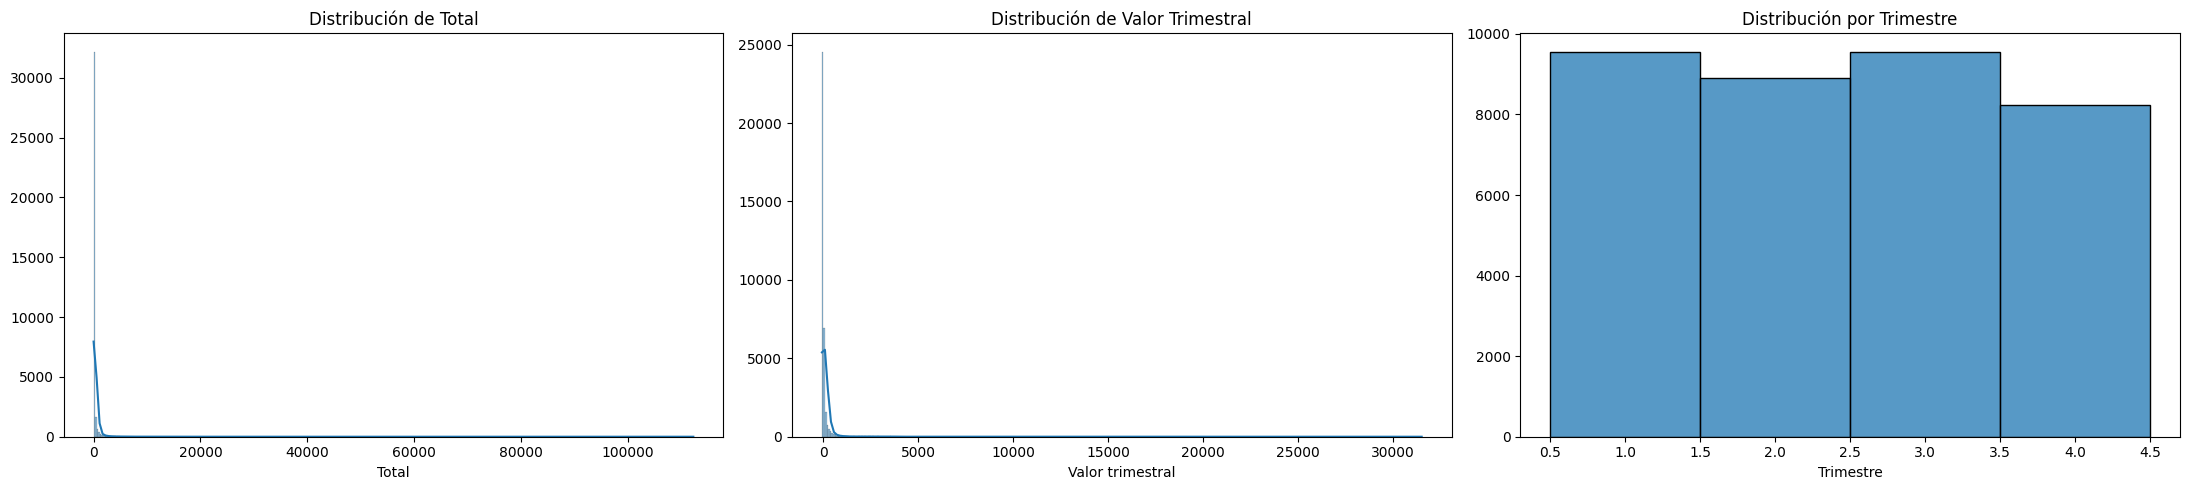

In [13]:
fig, axis = plt.subplots(1, 3, figsize=(22, 5))

sns.histplot(ax=axis[0], data=df_5, x='Total', kde=True)
axis[0].set_title('Distribución de Total')
axis[0].set_ylabel(None)

sns.histplot(ax=axis[1], data=df_5, x='Valor trimestral', kde=True)
axis[1].set_title('Distribución de Valor Trimestral')
axis[1].set_ylabel(None)

sns.histplot(ax=axis[2], data=df_5, x='Trimestre', discrete=True)
axis[2].set_title('Distribución por Trimestre')
axis[2].set_ylabel(None)



plt.tight_layout()
plt.show()


## Visualización de variables categóricas

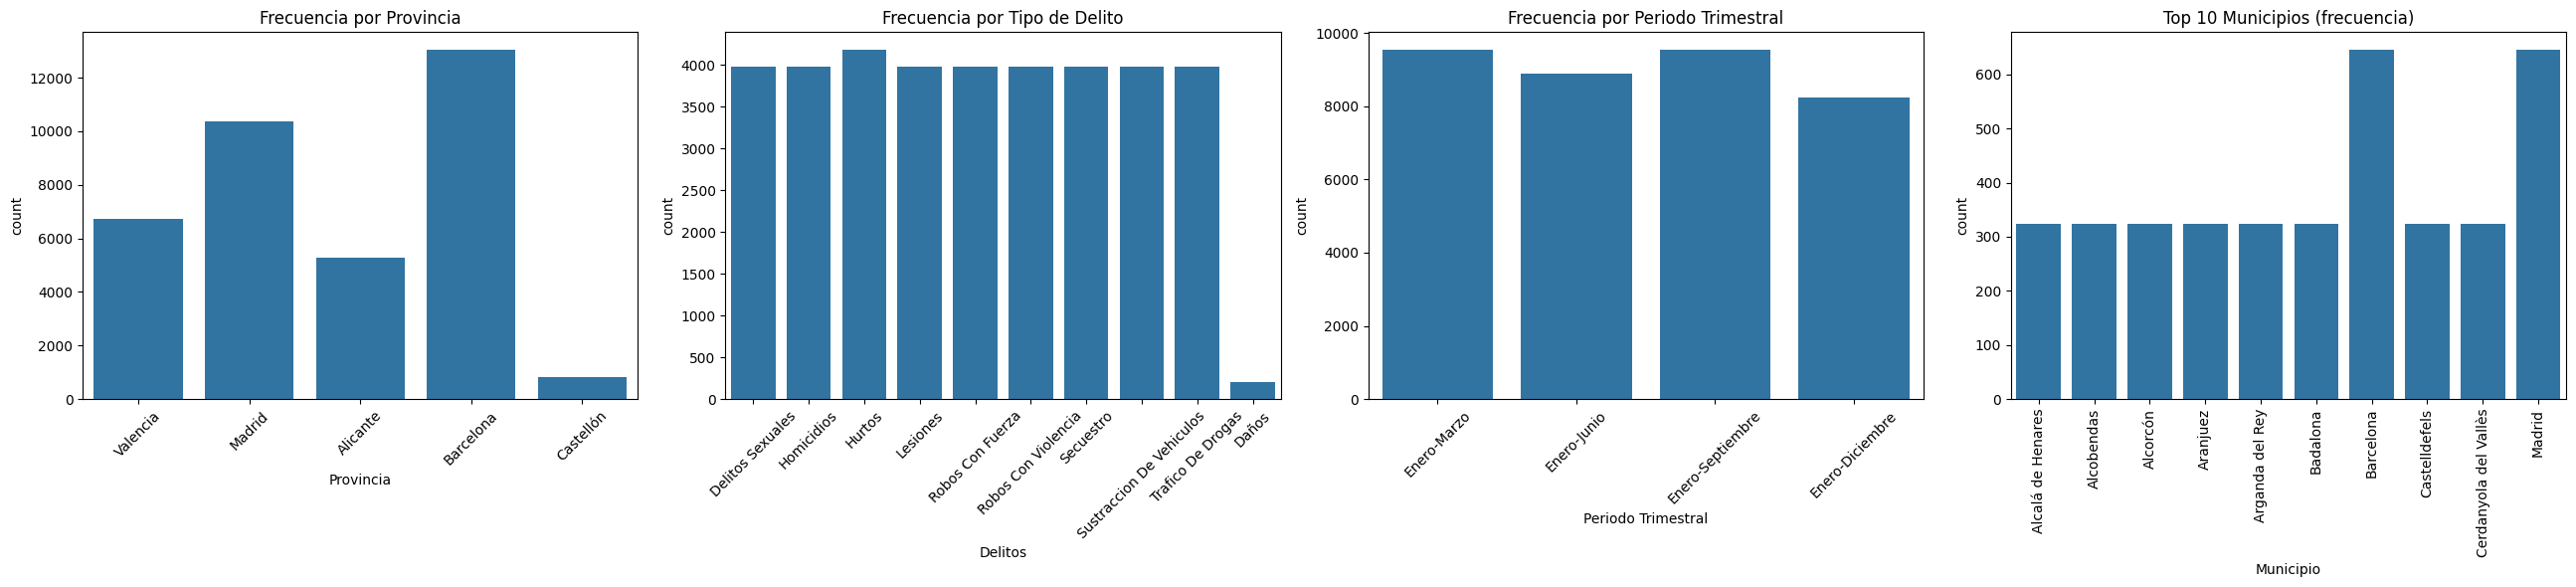

In [14]:
fig, axis = plt.subplots(1, 4, figsize=(26, 6))

sns.countplot(ax=axis[0], data=df_5, x='Provincia')
axis[0].set_title('Frecuencia por Provincia')
axis[0].tick_params(axis='x', rotation=45)

sns.countplot(ax=axis[1], data=df_5, x='Delitos')
axis[1].set_title('Frecuencia por Tipo de Delito')
axis[1].tick_params(axis='x', rotation=45)

sns.countplot(ax=axis[2], data=df_5, x='Periodo Trimestral')
axis[2].set_title('Frecuencia por Periodo Trimestral')
axis[2].tick_params(axis='x', rotation=45)


top_municipios = df_5['Municipio'].value_counts().head(10).index
sns.countplot(
    ax=axis[3],
    data=df_5[df_5['Municipio'].isin(top_municipios)],
    x='Municipio'
)
axis[3].set_title('Top 10 Municipios (frecuencia)')
axis[3].tick_params(axis='x', rotation=90)

plt.tight_layout()
plt.show()


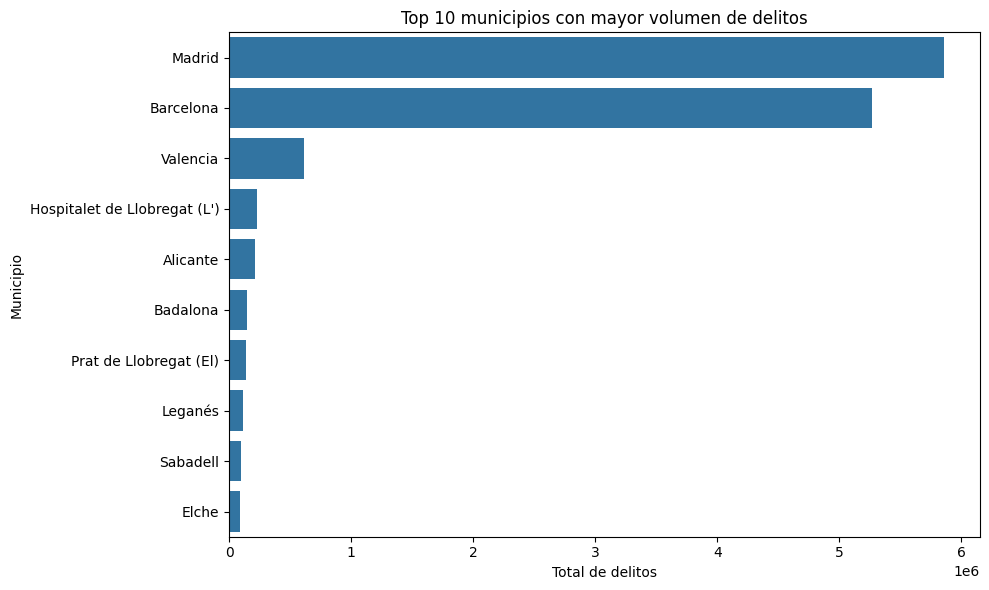

In [15]:
top_municipios = (df_5.groupby('Municipio')['Total'].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10, 6))
sns.barplot(x=top_municipios.values,y=top_municipios.index)

plt.title('Top 10 municipios con mayor volumen de delitos')
plt.xlabel('Total de delitos')
plt.ylabel('Municipio')
plt.tight_layout()
plt.show()


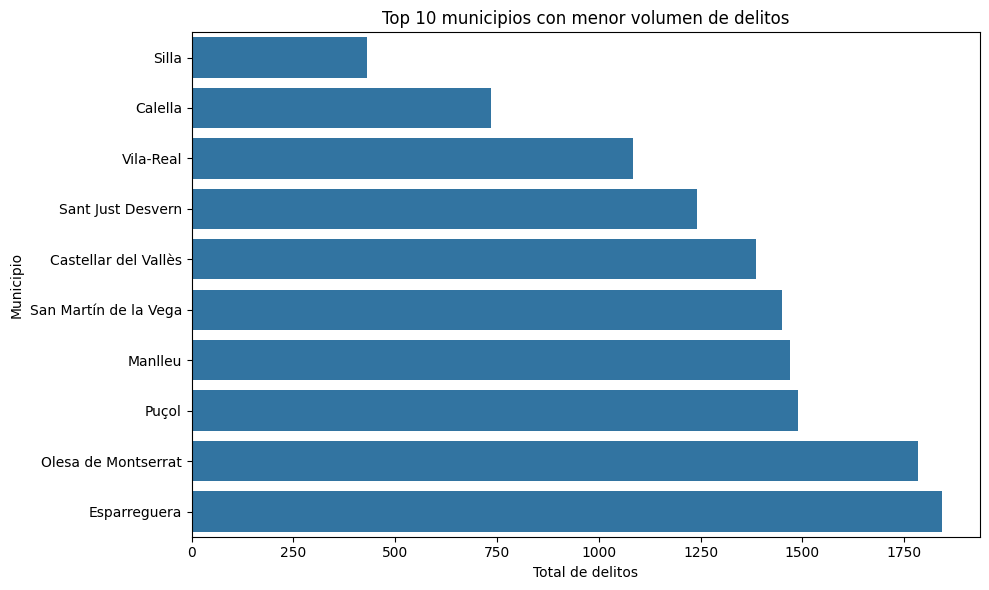

In [16]:
bottom_10_municipios = (df_5.groupby('Municipio')['Total'].sum().sort_values(ascending=True).head(10))

plt.figure(figsize=(10, 6))
sns.barplot(
    x=bottom_10_municipios.values,
    y=bottom_10_municipios.index
)

plt.title('Top 10 municipios con menor volumen de delitos')
plt.xlabel('Total de delitos')
plt.ylabel('Municipio')
plt.tight_layout()
plt.show()


In [17]:
top_municipios_provincia = (df_5.groupby(['Provincia', 'Municipio', 'Poblacion'])['Total'].sum().reset_index().sort_values(['Provincia', 'Total'], ascending=[True, False]))

top_municipios_provincia.groupby('Provincia').head(10)


,Provincia,Municipio,Poblacion,Total
17,Alicante,Alicante,1950357.0,26880
18,Alicante,Alicante,1991259.0,26428
16,Alicante,Alicante,1901594.0,22732
13,Alicante,Alicante,1858683.0,21446
10,Alicante,Alicante,1825332.0,21256
12,Alicante,Alicante,1838819.0,21224
11,Alicante,Alicante,1836459.0,18868
19,Alicante,Alicante,2030037.0,18004
15,Alicante,Alicante,1881762.0,17802
14,Alicante,Alicante,1879888.0,16525


## Observaciones y concluciones:

> - Las visualizaciones se organizaron diferenciando variables numéricas y categóricas, utilizando histogramas para analizar distribuciones y gráficos de frecuencia para variables discretas, con el objetivo de mejorar la interpretabilidad del análisis exploratorio.

## ANÁLISIS MULTIVARIANTE

> - Identificar dependencias

> - Detectar redundancias

> - Entender qué variables explican mejor el fenómeno

> - Preparar el terreno para el modelado

## MATRIZ DE CORRELACIÓN DE VARIABLES NUMERICAS

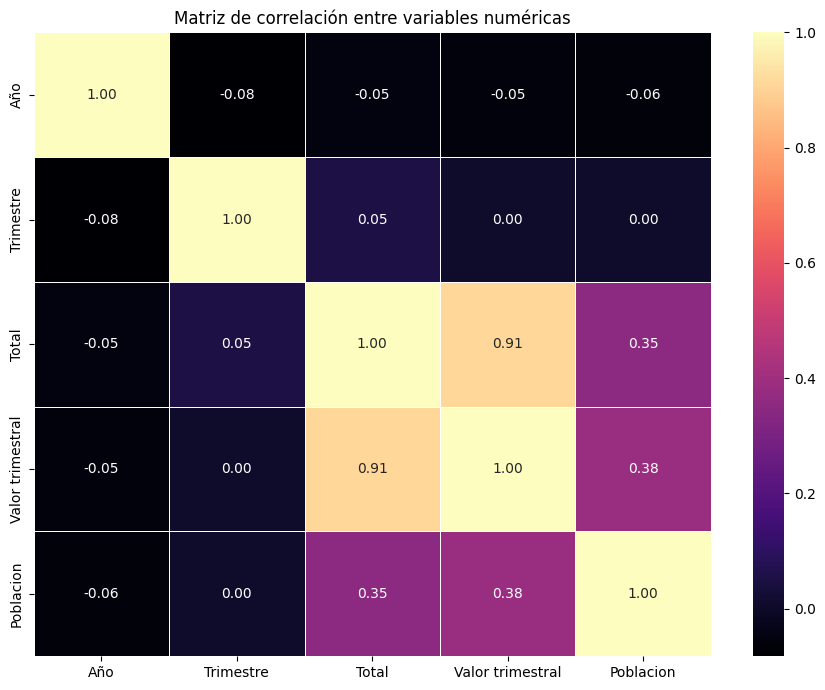

In [18]:
corr = df_5[['Año', 'Trimestre', 'Total', 'Valor trimestral', 'Poblacion']].corr()

plt.figure(figsize=(9, 7))
sns.heatmap(
    corr,
    annot=True,
    fmt=".2f",
    cmap="magma",
    linewidths=0.5
)

plt.title("Matriz de correlación entre variables numéricas")
plt.tight_layout()
plt.show()


## Observaciones y concluciones 

> - La matriz de correlación muestra una fuerte relación positiva entre el `total de delitos` y el `valor trimestral` (r = 0.91), lo que indica una elevada redundancia informativa entre ambas variables. Por otro lado, la `población` presenta una correlación positiva moderada con el volumen de delitos `(0.35–0.38)`, coherente con un efecto de escala poblacional más que con una mayor intensidad delictiva. Las variables temporales (`año` y `trimestre`) muestran correlaciones débiles con el resto, lo que sugiere que el comportamiento delictivo no sigue una tendencia lineal simple en el tiempo.

## Variable objetivo > `Total`

> - representa el volumen real de criminalidad
>
> - Total de delitos registrados por municipio y trimestre.

A partir del análisis multivariante se selecciona Total como variable objetivo, al representar directamente el volumen de criminalidad. La variable Valor trimestral se excluye del modelado debido a su alta colinealidad con el objetivo. Se mantienen como variables explicativas la población y las variables temporales, así como las variables espaciales, al aportar información complementaria sin redundancia significativa.